# LeetCode #122: Best Time to Buy and Sell Stock II

https://leetcode.com/problems/best-time-to-buy-and-sell-stock-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Peak-Valley (explicit trades) | O(n) | O(1) | Correct but verbose |
| **Greedy (sum positive diffs)** | **O(n)** | **O(1)** | **Optimal — collect every upward move** |

## Understanding the Method

Key insight: A[i]→A[k] gain = sum of all daily gains from i to k.
So we simply add every positive consecutive difference.

- If `prices[i] > prices[i-1]`: add `prices[i] - prices[i-1]` to profit
- Otherwise skip (ignore losses)

## Constraints

- `1 <= prices.length <= 3 * 10^4`
- `0 <= prices[i] <= 10^4`

## Solutions

### C#

In [ ]:
public class Solution {
    public int MaxProfit(int[] prices) {
        int profit = 0;
        for (int i = 1; i < prices.Length; i++)
            if (prices[i] > prices[i-1])
                profit += prices[i] - prices[i-1];
        return profit;
    }
}

### Python

In [ ]:
class Solution:
    def maxProfit(self, prices: list[int]) -> int:
        return sum(max(0, prices[i] - prices[i-1]) for i in range(1, len(prices)))

### Go

In [ ]:
func maxProfit(prices []int) int {
    profit := 0
    for i := 1; i < len(prices); i++ {
        if prices[i] > prices[i-1] {
            profit += prices[i] - prices[i-1]
        }
    }
    return profit
}

### Rust

In [ ]:
impl Solution {
    pub fn max_profit(prices: Vec<i32>) -> i32 {
        prices.windows(2).map(|w| (w[1] - w[0]).max(0)).sum()
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `prices = [7, 1, 5, 3, 6, 4]`  
Collect every positive consecutive difference: $(5-1) = 4$, $(6-3) = 3$. Total $= 7$. Equivalent to buy@1 sell@5, buy@3 sell@6.  
WHY tricky: Key insight is that a multi-day rise $A[i] \to A[k]$ equals the sum of daily gains. LaTeX: $\text{profit} = \sum_{i=1}^{n-1} \max(0,\, p_i - p_{i-1})$.

### 2. Slightly Complex -- Monotonically Increasing
**Input:** `prices = [1, 2, 3, 4, 5]`  
Every consecutive pair is profitable: $+1+1+1+1 = 4$. Equivalent to one trade: buy@1, sell@5. Greedy daily accumulation matches the single best trade.  
WHY tricky: Tempting to think you need to find the single best trade. Daily accumulation is equivalent and simpler. LaTeX: $\sum_{i=1}^{4} (p_i - p_{i-1}) = p_4 - p_0 = 4$.

### 3. Edge Case: Time Factor
**Input:** `prices = [0, 10000, 0, 10000, ...]` ($n = 30{,}000$ elements, alternating)  
15,000 positive diffs of 10,000 each. Single $O(n)$ pass, 30,000 comparisons. Total profit $= 15{,}000 \times 10{,}000 = 150{,}000{,}000$.  
WHY tricky: At max constraint size. Alternating pattern maximizes trade count. LaTeX: $O(n) = O(3 \times 10^4)$; result fits in 32-bit int since $1.5 \times 10^8 < 2^{31}$.

### 4. Edge Case: Space Factor
**Input:** `prices = [5, 5, 5, ..., 5]` (all identical, $n = 30{,}000$)  
Every diff $= 0$. Only one integer accumulator needed: $O(1)$ space regardless of input size. No auxiliary arrays or stacks.  
WHY tricky: Verifies constant space with no hidden allocations. LaTeX: $\text{space} = O(1)$ -- single variable `profit`.

### 5. Almost-Impossible but Plausible
**Input:** `prices = [10000, 9999, 9998, ..., 1, 0]` ($10{,}001$ elements, strictly decreasing)  
Every consecutive diff is $-1$. No positive diffs to collect. Profit stays $0$. Algorithm correctly skips every pair.  
WHY tricky: Worst-case for profit: zero. Algorithm doesn't force a trade when none is profitable. LaTeX: $\max(0, p_i - p_{i-1}) = 0\;\forall\; i$.

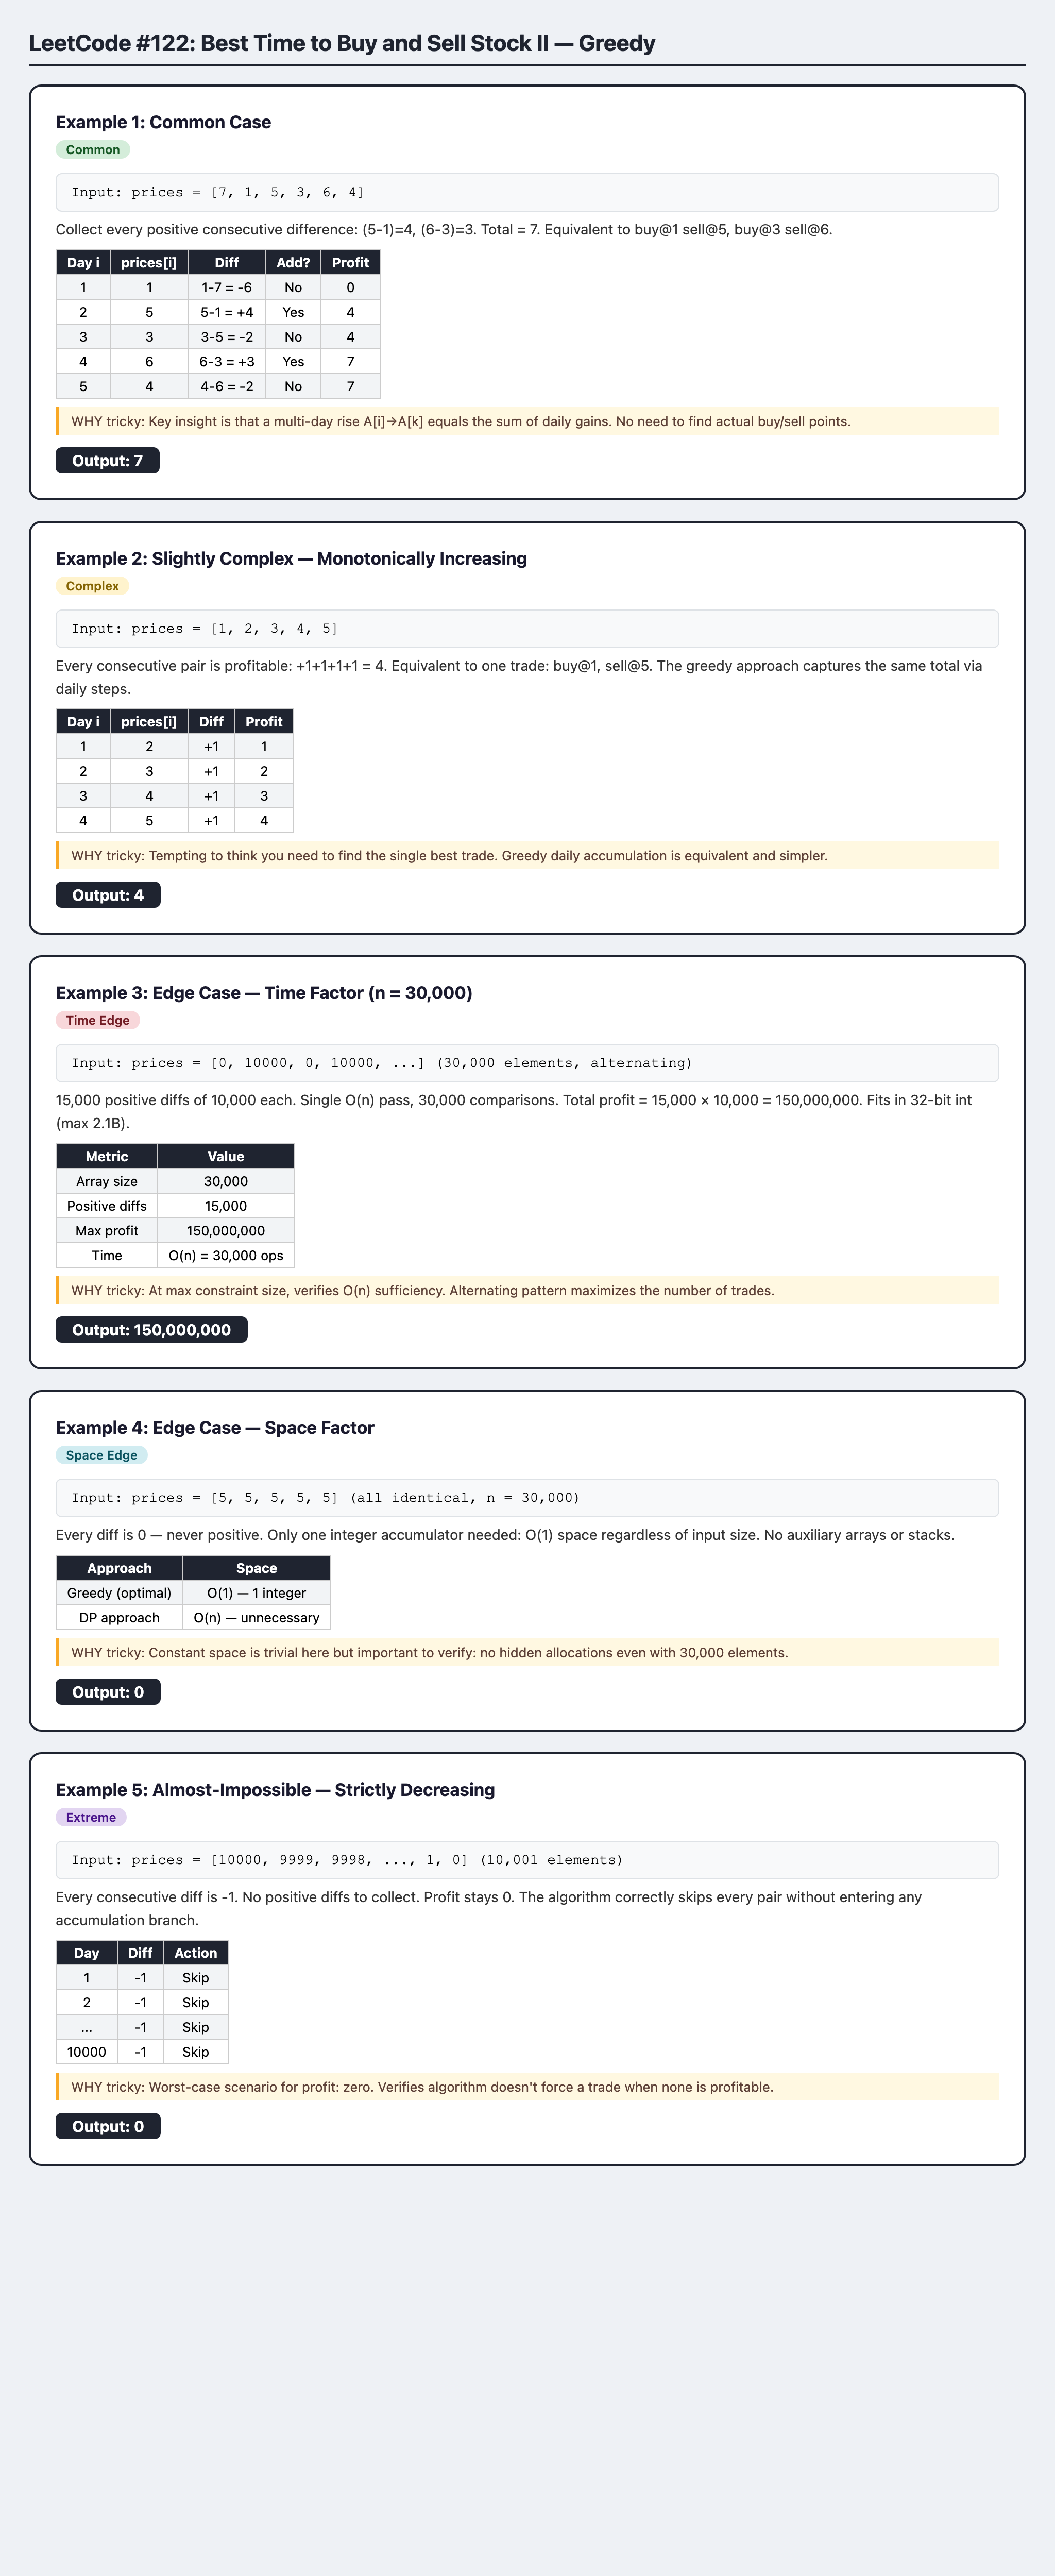